In [1]:
pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/raw/Customer_Data.csv")
df.head()

,LAN,Customer ID,Customer Name,Age,State,District,Manufacturer,Vehicle_Model,Existing Customer,Loan amount requested,Loan_tenure(years),Cibil Score,Obligation,Land acres,Crop,Other_documented_income,DPD,Status
0,4,FE4,Monika Gupta,39,Karnataka,Mysuru,KOMA,KX00003,Yes,448588,3,747,87666,2,Rice,498178,0.0,Disbursed
1,5,FE5,Priya Wadwa,33,Karnataka,Channarayapatna,KOMA,KX00003,No,754946,6,677,89413,2,Maize,330556,0.0,Disbursed
2,6,FE6,Tarang S,59,Maharashtra,Pune,KOMA,KX00003,Yes,895696,4,717,157834,1,Rice,273521,114.0,Disbursed
3,9,FE9,Sita Kumari,25,Madhya Pradesh,Dhulagori,KOMA,KX00003,No,823123,5,678,22817,1,Cotton,578129,38.0,Disbursed
4,10,FE10,Suraj Sharma,47,Gujarat,Ahmedabad,KOMA,KX00003,No,473162,3,621,47059,8,Maize,594447,0.0,Disbursed


In [3]:
#Data quality
df.describe()

,LAN,Age,Loan amount requested,Loan_tenure(years),Cibil Score,Obligation,Land acres,Other_documented_income,DPD
count,119707.000000,119707.000000,119707.000000,119707.000000,119707.000000,119707.000000,119707.000000,119707.000000,112973.000000
mean,99797.561713,38.534380,661225.560652,4.502051,674.545816,110255.592447,2.836693,399927.588362,7.797208
std,57773.869246,11.276536,166056.082732,1.117323,45.965351,86220.330958,2.167024,117040.600892,43.745199
min,4.000000,16.000000,400001.000000,3.000000,-1.000000,0.000000,1.000000,100000.000000,0.000000
25%,49767.500000,30.000000,500000.000000,4.000000,637.000000,50024.500000,1.000000,299143.500000,0.000000
50%,99761.000000,37.000000,643161.000000,5.000000,675.000000,100118.000000,2.000000,399456.000000,0.000000
75%,149721.500000,47.000000,796967.000000,5.000000,713.000000,150088.000000,4.000000,499175.500000,0.000000
max,200000.000000,64.000000,999988.000000,6.000000,750.000000,499984.000000,8.000000,710000.000000,380.000000


In [4]:
df = df.drop_duplicates()

In [5]:
df.isnull().sum()

LAN                           0
Customer ID                   0
Customer Name                 0
Age                           0
State                         0
District                      0
Manufacturer                  0
Vehicle_Model                 0
Existing Customer             0
Loan amount requested         0
Loan_tenure(years)            0
Cibil Score                   0
Obligation                    0
Land acres                    0
Crop                          0
Other_documented_income       0
DPD                        6734
Status                        0
dtype: int64

In [6]:
df.shape

(119707, 18)

In [7]:
for column in df.columns:
    print(f"{column}: {df[column].dtype}")

LAN: int64
Customer ID: str
Customer Name: str
Age: int64
State: str
District: str
Manufacturer: str
Vehicle_Model: str
Existing Customer: str
Loan amount requested: int64
Loan_tenure(years): int64
Cibil Score: int64
Obligation: int64
Land acres: int64
Crop: str
Other_documented_income: int64
DPD: float64
Status: str


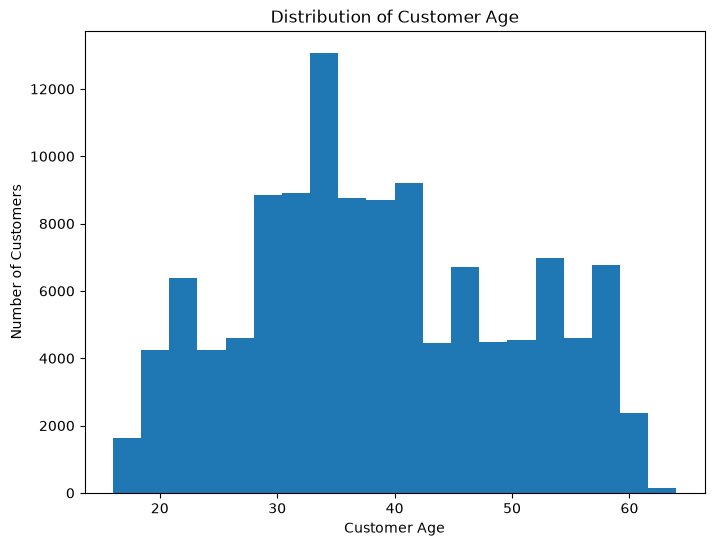

In [8]:
#Customer Analysis
plt.figure(figsize=(8, 6))

plt.hist(df["Age"], bins=20)

plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Age")

plt.show()

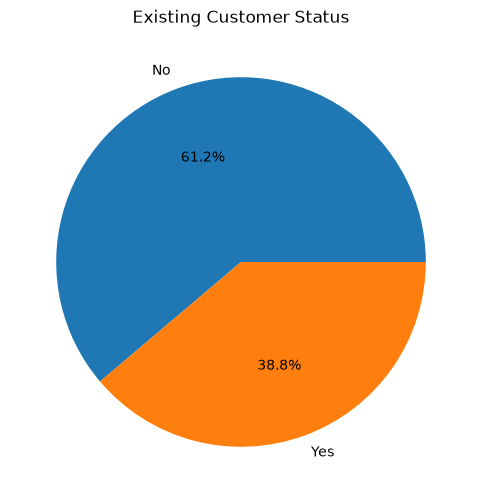

In [9]:
customer_status = df["Existing Customer"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    customer_status,
    labels=customer_status.index,
    autopct="%1.1f%%"
)

plt.title("Existing Customer Status")

plt.show()

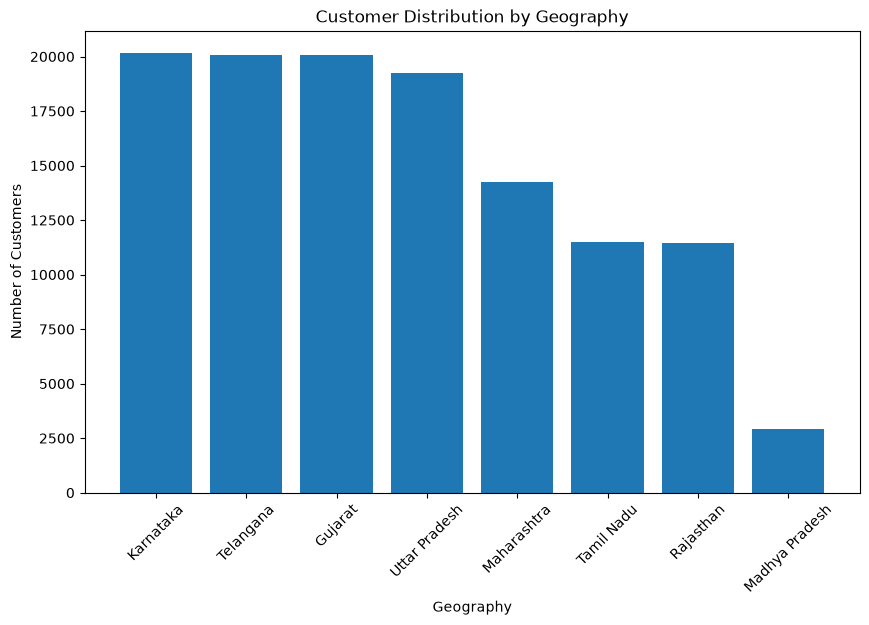

In [10]:
geography_counts = df["State"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    geography_counts.index,
    geography_counts.values
)

plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Geography")

plt.xticks(rotation=45)

plt.show()

In [11]:

df["Default"] = (df["DPD"] > 0).astype(int)

df[["DPD", "Default"]].head()


,DPD,Default
0,0.0,0
1,0.0,0
2,114.0,1
3,38.0,1
4,0.0,0


In [12]:
disbursed_cases = (df["Status"] == "Disbursed").sum()

print("Number of disbursed cases:", disbursed_cases)

Number of disbursed cases: 112973


In [ ]:
#Credit Risk Analysis
customers_below_650 = (df["Cibil Score"] < 650).sum()

total_customers = len(df)

percentage = (customers_below_650 / total_customers) * 100

print(f"Percentage of customers with a CIBIL score below 650: {percentage:.2f}%")

In [13]:
disbursed_df = df[df["Status"] == "Disbursed"]

default_rate = disbursed_df["Default"].mean() * 100

print(f"Default Rate of Disbursed Cases: {default_rate:.2f}%")

Default Rate of Disbursed Cases: 3.94%


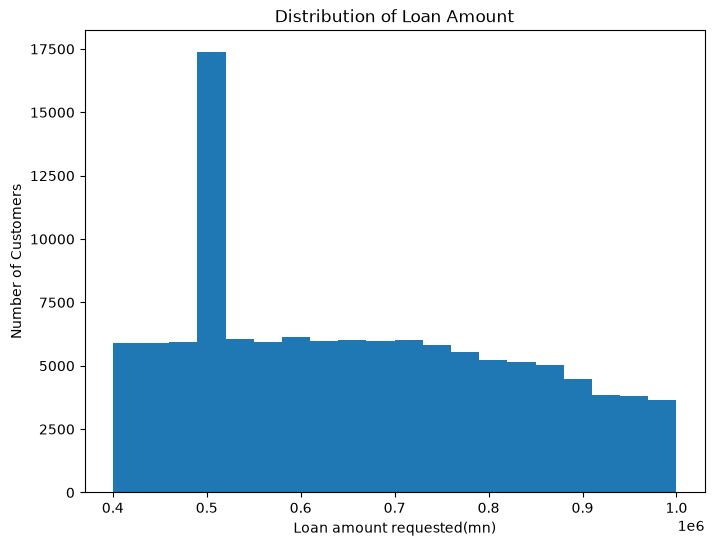

In [14]:
#Loan analysis
plt.figure(figsize=(8, 6))

plt.hist(df["Loan amount requested"], bins=20)

plt.xlabel("Loan amount requested(mn)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Loan Amount")

plt.show()

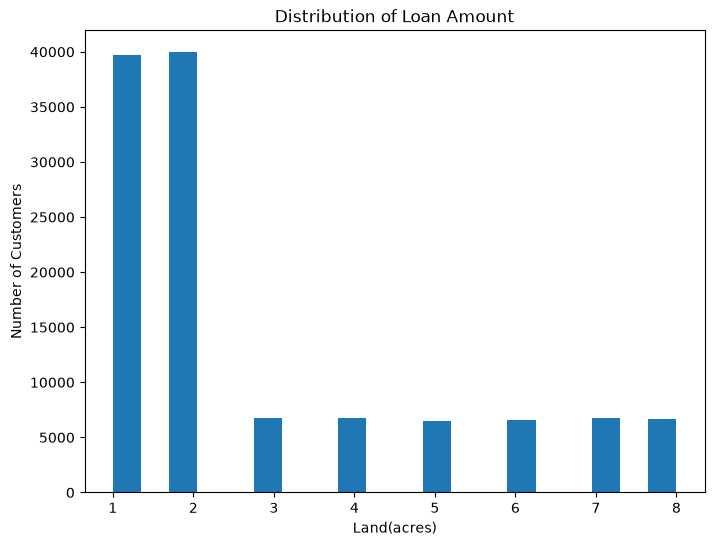

In [15]:
#Agriculture analysis
plt.figure(figsize=(8, 6))

plt.hist(df["Land acres"], bins=20)

plt.xlabel("Land(acres)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Loan Amount")

plt.show()

In [16]:
top_manuf = df["Manufacturer"].value_counts()
print(top_manuf.head(3))

Manufacturer
WAGOE    17063
NHD      15800
SON      15605
Name: count, dtype: int64


In [17]:
top_models = df["Vehicle_Model"].value_counts()
print(top_models.head(3))

Vehicle_Model
NX00003    6321
TX00003    6318
WX00002    6271
Name: count, dtype: int64
